In [4]:
from pathlib import Path
import pandas as pd
import zipfile
from collections import Counter
import matplotlib.pyplot as plt
import csv

labelled_channels = pd.read_csv("/Volumes/StudyNProjects/Python/ESA-Mission1/labels.csv")
anamoly_types = pd.read_csv("/Volumes/StudyNProjects/Python/ESA-Mission1/anomaly_types.csv")
channels = pd.read_csv("/Volumes/StudyNProjects/Python/ESA-Mission1/channels.csv")
telecommand = pd.read_csv("/Volumes/StudyNProjects/Python/ESA-Mission1/telecommands.csv")
telecommand_folder = Path("/Volumes/StudyNProjects/Python/ESA-Mission1/telecommands")
unzip_telecommand = list(telecommand_folder.glob("*.zip"))
channel_folder = Path("/Volumes/StudyNProjects/Python/ESA-Mission1/channels")
unzip_channel = list(channel_folder.glob("*.zip"))


In [5]:
selected_event_id = labelled_channels.loc[labelled_channels["ID"] =="id_9"]
available_channel_labelled_event = set(selected_event_id["Channel"])

selected_event_id["StartTime"] = pd.to_datetime(selected_event_id["StartTime"])
selected_event_id["EndTime"] = pd.to_datetime(selected_event_id["EndTime"])

event_start = selected_event_id["StartTime"].min()
event_end = selected_event_id["EndTime"].max()

buffer_s_time = event_start - pd.Timedelta(days=1)
buffer_e_time = event_end + pd.Timedelta(days=1)
sliced={}
for channel in unzip_channel:

    with zipfile.ZipFile(channel, "r") as archive:

        for internal_file in archive.namelist():

            if internal_file not in available_channel_labelled_event:
                continue

            with archive.open(internal_file, "r") as files:
                inside_channel_files = pd.read_pickle(files)
            
            inside_channel_files.index = pd.to_datetime(inside_channel_files.index, utc=True)  

            inside_buffer = (
                (inside_channel_files.index >= buffer_s_time)
                &
                (inside_channel_files.index <= buffer_e_time)
            )
            sliced_channel = inside_channel_files.loc[inside_buffer]

            sliced[internal_file] = {
                "data":sliced_channel,
                
            }
print(sliced.keys())
print(sliced["channel_14"])

/var/folders/nt/_x879mv56q3dx4771j9lrtdh0000gn/T/ipykernel_16128/1874015422.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_event_id["StartTime"] = pd.to_datetime(selected_event_id["StartTime"])
/var/folders/nt/_x879mv56q3dx4771j9lrtdh0000gn/T/ipykernel_16128/1874015422.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_event_id["EndTime"] = pd.to_datetime(selected_event_id["EndTime"])


dict_keys(['channel_29', 'channel_14', 'channel_21'])
{'data':                                   channel_14
datetime                                    
2003-02-11 07:00:15.510000+00:00    0.303240
2003-02-11 07:01:45.510000+00:00    0.306254
2003-02-11 07:03:15.510000+00:00    0.303240
2003-02-11 07:04:45.510000+00:00    0.303240
2003-02-11 07:06:15.510000+00:00    0.303240
...                                      ...
2003-02-13 08:00:15.510000+00:00    0.336745
2003-02-13 08:01:45.510000+00:00    0.336745
2003-02-13 08:03:15.510000+00:00    0.336745
2003-02-13 08:04:45.510000+00:00    0.336745
2003-02-13 08:06:15.510000+00:00    0.336745

[1965 rows x 1 columns]}


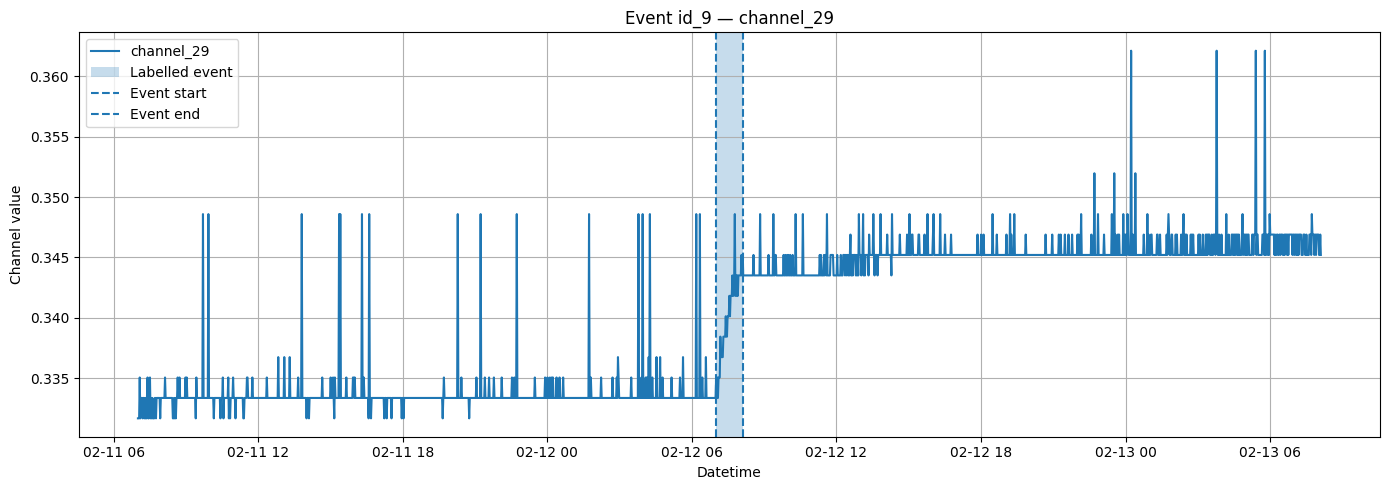

In [6]:
import matplotlib.pyplot as plt

channel_name = "channel_29"

channel_df = sliced[channel_name]["data"]

value_column = channel_df.columns[0]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    channel_df.index,
    channel_df[value_column],
    label=channel_name
)

ax.axvspan(
    event_start,
    event_end,
    alpha=0.25,
    label="Labelled event"
)

ax.axvline(
    event_start,
    linestyle="--",
    label="Event start"
)

ax.axvline(
    event_end,
    linestyle="--",
    label="Event end"
)

ax.set_title(f"Event id_9 — {channel_name}")
ax.set_xlabel("Datetime")
ax.set_ylabel("Channel value")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

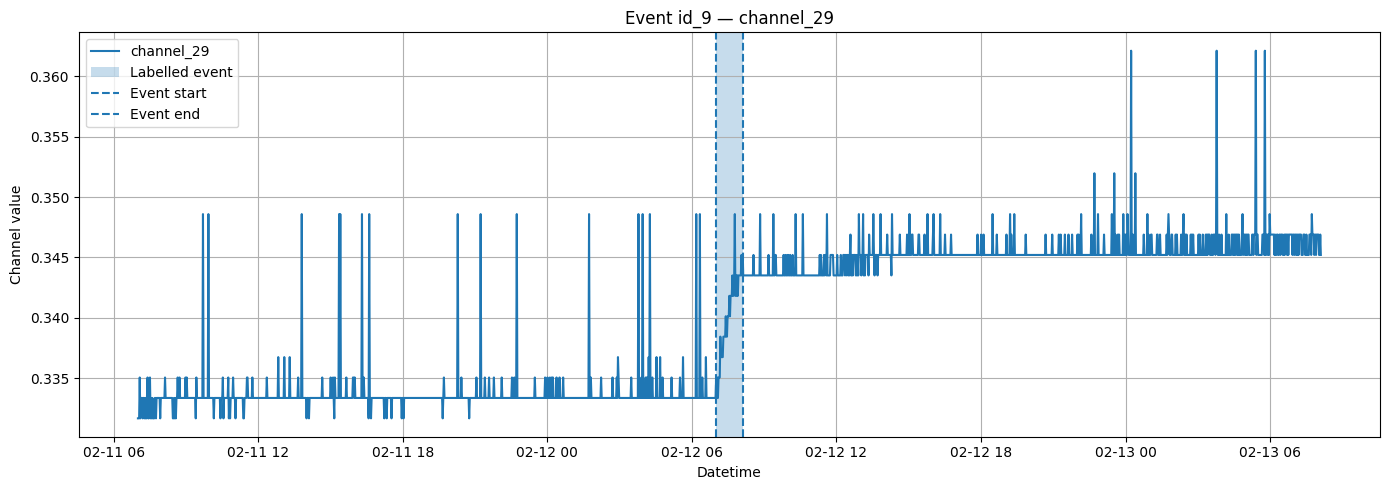

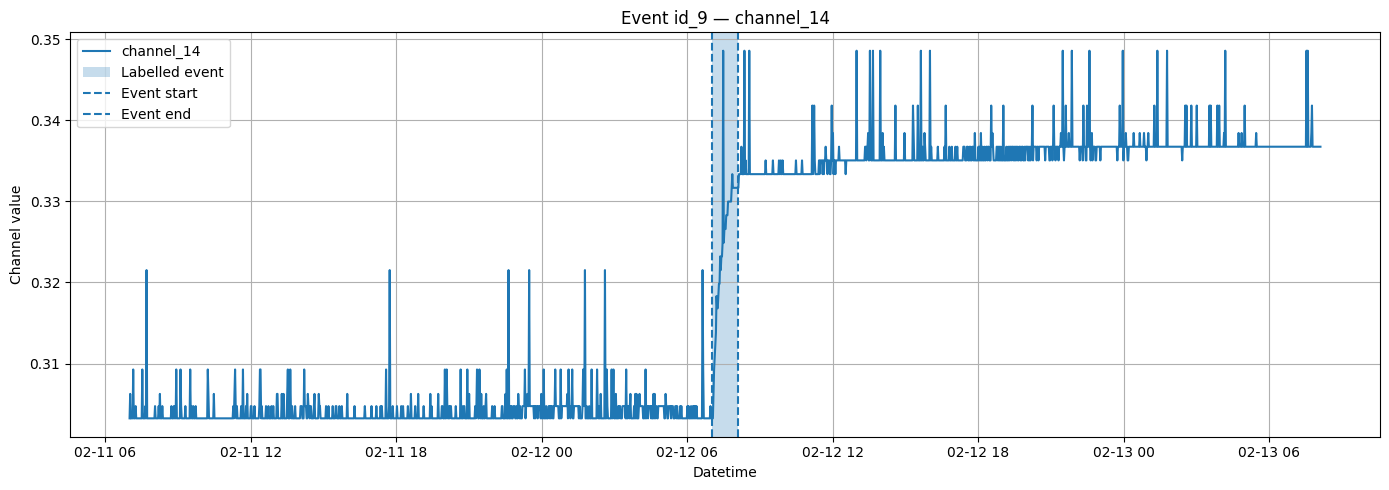

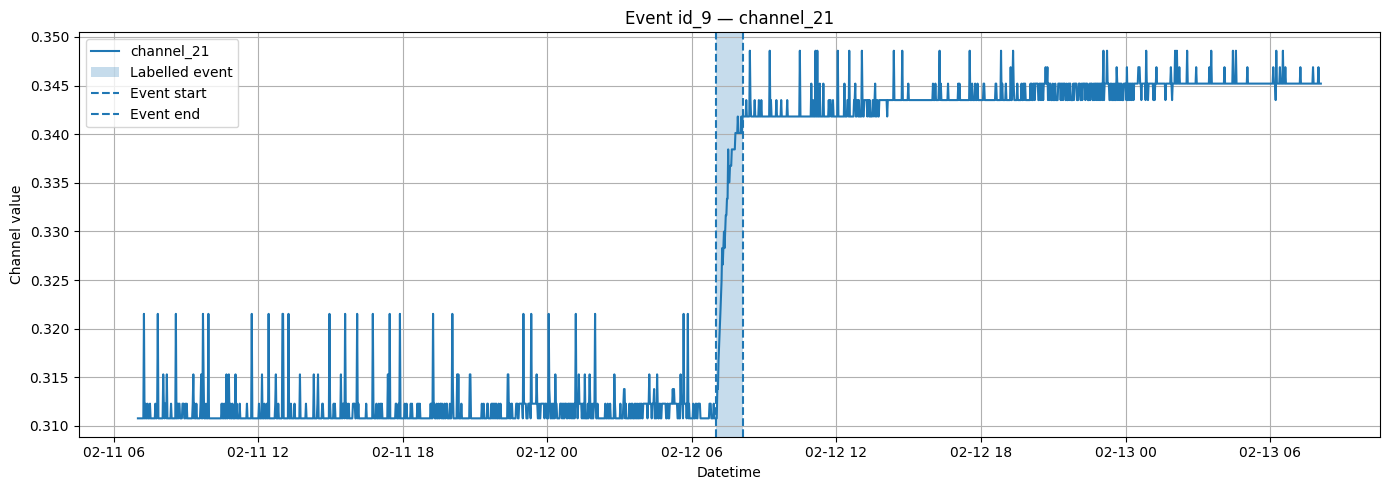

In [7]:
import matplotlib.pyplot as plt

for channel_name, channel_content in sliced.items():

    channel_df = channel_content["data"]
    value_column = channel_df.columns[0]

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        channel_df.index,
        channel_df[value_column],
        label=channel_name
    )

    ax.axvspan(
        event_start,
        event_end,
        alpha=0.25,
        label="Labelled event"
    )

    ax.axvline(
        event_start,
        linestyle="--",
        label="Event start"
    )

    ax.axvline(
        event_end,
        linestyle="--",
        label="Event end"
    )

    ax.set_title(f"Event id_9 — {channel_name}")
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Channel value")

    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

In [12]:
telecommand_event=[]
events_channel_id = sliced.keys()
print(events_channel_id)
for each_telecommand in unzip_telecommand:
    with zipfile.ZipFile(each_telecommand, "r") as archive:
       for interal_telecommand_file in archive.namelist():
           with archive.open(interal_telecommand_file,"r") as file_stream:
               
               telecommand_df = pd.read_pickle(file_stream)
               telecommand_df.index = pd.to_datetime(telecommand_df.index, utc=True)
               sliced_telecommand = telecommand_df.loc[(telecommand_df.index>=buffer_s_time)& (telecommand_df.index <= buffer_e_time)]
               mask = ((telecommand_df.index >= buffer_s_time)&(telecommand_df.index <= buffer_e_time))   
               #print("Matching rows:", mask.sum())
               if sliced_telecommand.empty:
                   continue
               telecommand_name = sliced_telecommand.columns[0]
               temp = pd.DataFrame({
                   "dateTime": sliced_telecommand.index,
                   "telecommand_name":telecommand_name,
                   "value": sliced_telecommand[telecommand_name].values
               })
               telecommand_event.append(temp)
print(telecommand_event)
print("Event buffer Start",buffer_s_time)
print("Event buffer end",buffer_e_time)

dict_keys(['channel_29', 'channel_14', 'channel_21'])
[                          dateTime telecommand_name  value
0 2003-02-12 16:45:03.657000+00:00  telecommand_197      1,                           dateTime telecommand_name  value
0 2003-02-12 15:00:00.006000+00:00   telecommand_60      1,                           dateTime telecommand_name  value
0 2003-02-12 16:55:16.398000+00:00  telecommand_195      1,                           dateTime telecommand_name  value
0 2003-02-12 17:08:19.161000+00:00  telecommand_556      1,                           dateTime telecommand_name  value
0 2003-02-12 09:51:56.442000+00:00  telecommand_231      1
1 2003-02-12 10:30:56.445000+00:00  telecommand_231      1
2 2003-02-12 22:14:29.475000+00:00  telecommand_231      1
3 2003-02-12 22:50:29.475000+00:00  telecommand_231      1,                           dateTime telecommand_name  value
0 2003-02-12 17:07:18.261000+00:00  telecommand_557      1,                           dateTime telecommand_name  v

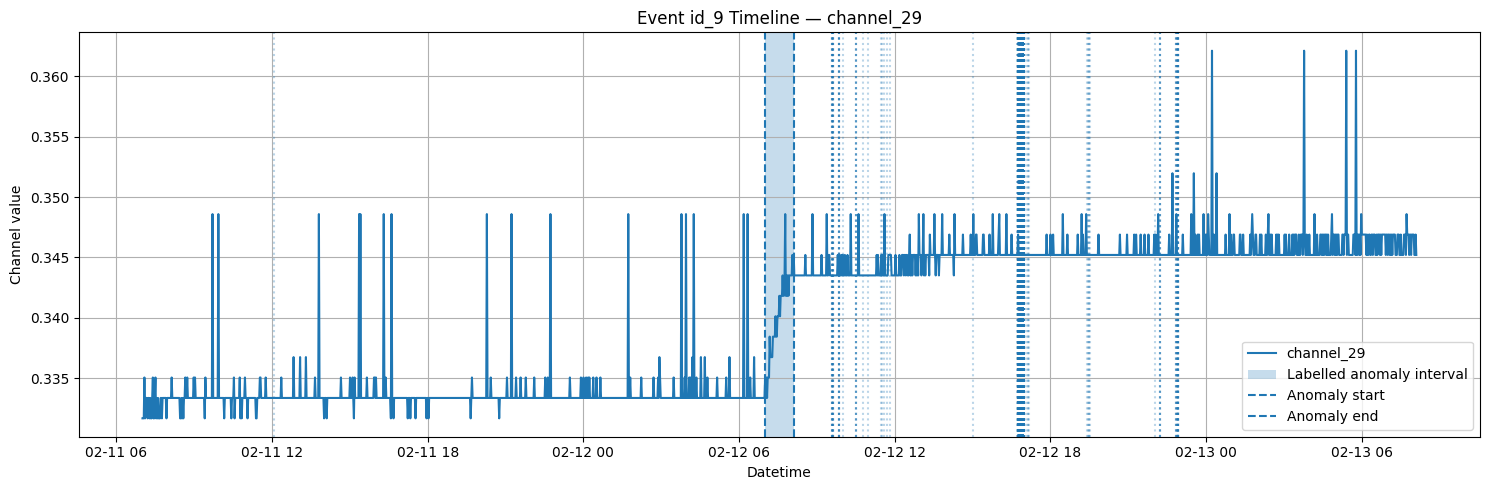

In [16]:
import matplotlib.pyplot as plt

# Choose one affected channel
channel_name = "channel_29"

# Get channel data from sliced dictionary
channel_df = sliced[channel_name]["data"]
value_column = channel_df.columns[0]

# Create plot
fig, ax = plt.subplots(figsize=(15, 5))

# 1. Plot channel signal
ax.plot(
    channel_df.index,
    channel_df[value_column],
    label=channel_name
)

# 2. Shade labelled anomaly interval
ax.axvspan(
    event_start,
    event_end,
    alpha=0.25,
    label="Labelled anomaly interval"
)

# 3. Mark anomaly start and end
ax.axvline(
    event_start,
    linestyle="--",
    label="Anomaly start"
)

ax.axvline(
    event_end,
    linestyle="--",
    label="Anomaly end"
)
final_telecommand_table = pd.concat(
    telecommand_event,
    ignore_index=True
)
final_telecommand_table = final_telecommand_table.sort_values(
    "dateTime"
)
# 4. Add telecommand markers
for command_time in final_telecommand_table["dateTime"]:
    ax.axvline(
        command_time,
        linestyle=":",
        alpha=0.3
    )

# Labels
ax.set_title(f"Event id_9 Timeline — {channel_name}")
ax.set_xlabel("Datetime")
ax.set_ylabel("Channel value")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
'''
2003-02-11 07:00:15.510000+00:00 
2003-02-12 07:00:15.510000+00:00 e_s
2003-02-12 08:06:15.510000+00:00 e_e
2003-02-13 08:06:15.510000+00:00
'''

channel_slice ={}



for key, values in sliced.items(): 
    dataFrame = values["data"];
    df = pd.DataFrame(dataFrame)

    for channel in df.columns:

        channel_df_sliced = df[[channel]]
        filter_phase_during = channel_df_sliced.loc[event_start:event_end]
        filter_phase_before = channel_df_sliced.loc[buffer_s_time:event_start]
        filter_phase_after = channel_df_sliced.loc[event_end:buffer_e_time]

        channel_slice[channel]={
            "before":filter_phase_before,
            "during":filter_phase_during,
            "after": filter_phase_after
        }

print(channel_slice)
#print(sliced)



    

In [143]:
simple_preprocess =[]

for channel , phases in channel_slice.items():
    for phase_name,phase_df in phases.items():
            dataFrame = phase_df[channel]
            rows ={
                "channel":channel,
                "phase": phase_name,
                "mean": dataFrame.mean(),
                "std": dataFrame.std(),
                "min":dataFrame.min(),
                "max":dataFrame.max(),
                "count": dataFrame.count()
                }
            #print("Phase_name =", phase_name,"\nDescribe\n",phase_df.describe())
            simple_preprocess.append(rows)
summary_df = pd.DataFrame(simple_preprocess)
print(summary_df)

      channel   phase      mean       std       min       max  count
0  channel_29  before  0.333678  0.002043  0.331674  0.348588    961
1  channel_29  during  0.340205  0.003532  0.333362  0.348588     45
2  channel_29   after  0.345399  0.001605  0.343510  0.362118    961
3  channel_14  before  0.304060  0.002000  0.303240  0.321526    961
4  channel_14  during  0.324177  0.009631  0.303240  0.348588     45
5  channel_14   after  0.336173  0.002304  0.331674  0.348588    961
6  channel_21  before  0.311622  0.001899  0.310782  0.321526    961
7  channel_21  during  0.332255  0.009259  0.310782  0.341822     45
8  channel_21   after  0.344107  0.001514  0.341822  0.348588    961


In [171]:

abs_calc = summary_df.copy()
mean_shift_rows =[]

for channel_name in abs_calc["channel"].unique():
    channels_rows = abs_calc[abs_calc["channel"]==channel_name]
    before_mean = channels_rows.loc[channels_rows["phase"] =="before", "mean"].iloc[0]
    during_mean = channels_rows.loc[channels_rows["phase"] =='during',"mean"].iloc[0]
    after_mean = channels_rows.loc[channels_rows["phase"]=='after','mean'].iloc[0]
    mean_shift = abs(during_mean - before_mean)
    af_dur_shift = abs(after_mean - during_mean)
    af_bf_shift = abs(after_mean - before_mean)
    before_std = channels_rows.loc[channels_rows["phase"]=="before","std"].iloc[0]
    during_std = channels_rows.loc[channels_rows["phase"]=="during","std"].iloc[0]
    std_shift = abs(during_std - before_std)
    anamoly_score = abs(mean_shift) + abs(std_shift)
    

    row = {
        "channel": channel_name,
        "before_mean": before_mean,
        "during_mean": during_mean,
        "after_mean": after_mean,
        "mean_shift": mean_shift,
        "after_during": af_dur_shift,
        "after_before" : af_bf_shift,
        "before_std": before_std,
        "during_std": during_std,
        "std_shift": std_shift,
        "anamoly_score": anamoly_score
        }
    mean_shift_rows.append(row)
    

mean_shift_df = pd.DataFrame(mean_shift_rows)
print(mean_shift_df)


      channel  before_mean  during_mean  after_mean  mean_shift  after_during  \
0  channel_29     0.333678     0.340205    0.345399    0.006527      0.005195   
1  channel_14     0.304060     0.324177    0.336173    0.020117      0.011996   
2  channel_21     0.311622     0.332255    0.344107    0.020633      0.011853   

   after_before  before_std  during_std  std_shift  anamoly_score  
0      0.011721    0.002043    0.003532   0.001490       0.008016  
1      0.032112    0.002000    0.009631   0.007632       0.027748  
2      0.032486    0.001899    0.009259   0.007360       0.027993  
